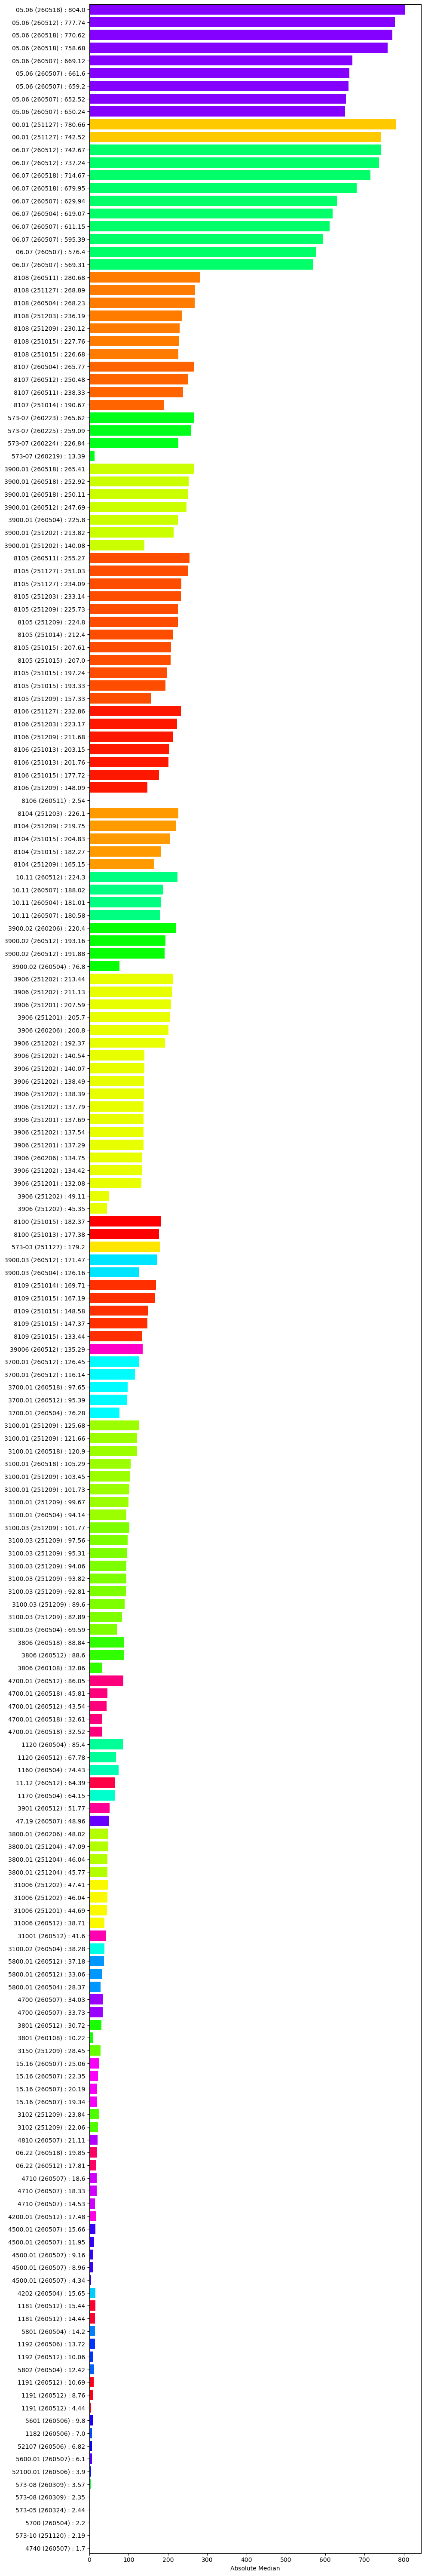

In [2]:
#strava valor absolut
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_path = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs\database\records.csv"

df = pd.read_csv(csv_path, sep=",")

df = df.copy()

df["abs_Median"] = df["median"].abs()
df = df.dropna(subset=["abs_Median"])
df = df[df["abs_Median"] > 1]

df["group_max"] = df.groupby("point_id")["abs_Median"].transform("max")


df_sorted = df.sort_values(
    ["group_max", "abs_Median"],
    ascending=[False, False]
)

df_sorted["label"] = (
    df_sorted["point_id"].astype(str)
    + " (" + df_sorted["date"].astype(str)
    + ") : "
    + df_sorted["abs_Median"].round(2).astype(str)
)

unique_points = df["point_id"].unique()

colors = plt.cm.hsv(np.linspace(0, 1, len(unique_points)))
color_map = dict(zip(unique_points, colors))

bar_colors = df_sorted["point_id"].map(color_map)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, max(2, len(df_sorted) * 0.3)))

plt.barh(
    df_sorted["label"],
    df_sorted["abs_Median"],
    color=bar_colors
)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Median")
plt.tight_layout()
plt.margins(y=0)
plt.show()

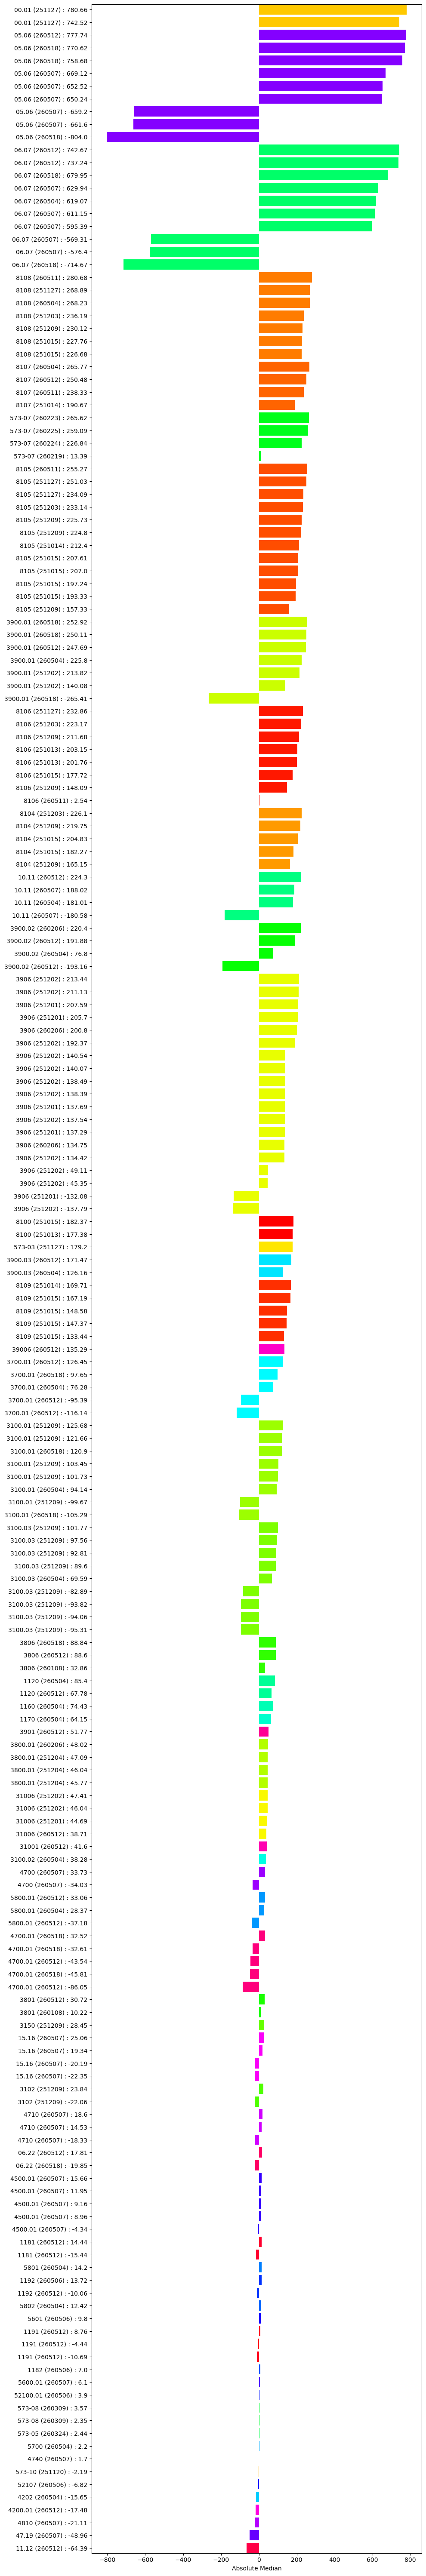

In [ ]:
# Strava 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_path = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs\database\records.csv"

df = pd.read_csv(csv_path, sep=",")

df = df.copy()


df["abs_Median"] = df["median"]
df = df.dropna(subset=["abs_Median"])
df = df[(df["median"] > 1) | (df["median"] < -1)]

df["group_max"] = df.groupby("point_id")["abs_Median"].transform("max")


df_sorted = df.sort_values(
    ["group_max", "abs_Median"],
    ascending=[False, False]
)

df_sorted["label"] = (
    df_sorted["point_id"].astype(str)
    + " (" + df_sorted["date"].astype(str)
    + ") : "
    + df_sorted["abs_Median"].round(2).astype(str)
)

unique_points = df["point_id"].unique()

colors = plt.cm.hsv(np.linspace(0, 1, len(unique_points)))
color_map = dict(zip(unique_points, colors))

bar_colors = df_sorted["point_id"].map(color_map)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, max(2, len(df_sorted) * 0.3)))

plt.barh(
    df_sorted["label"],
    df_sorted["abs_Median"],
    color=bar_colors
)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Median")
plt.tight_layout()
plt.margins(y=0)
plt.show()